# Part 1: Are Offices in Distress?

This notebook tests whether office-backed loans have higher average severity than mixed-use properties containing offices and non-office properties. It validates the loan-to-property merge, applies a documented classification rule, reports the requested group means, and checks whether the conclusion is sensitive to loan balance or target values above the stated range.

## Analysis decisions

- The unit of analysis is one loan because severity is supplied at loan level.
- `property_data.csv` is joined to `loan_data.csv` using `propname` with a validated many-to-one merge.
- `cssaproptype == 'OF'` defines single-purpose office properties.
- Any non-dedicated property whose detailed property type contains the word `office` is classified as mixed-use with office, even when its broad CSSA code is not `MU`.
- Mixed-use properties with missing detailed type are reported as unknown and excluded from the requested three-group comparison.
- Because the assignment defines severity on `[0, 1]`, the primary target clips the 108 supplied values above one to one. Raw supplied severity is retained as a separately labeled sensitivity.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_SEED = 20260901
N_BOOTSTRAP = 2_000

def require(condition: bool, message: str) -> None:
    """Raise a readable data-contract error.

    Args:
        condition: Condition that must evaluate to true.
        message: Explanation of the violated contract.

    Raises:
        ValueError: If condition is false.
    """
    if not condition:
        raise ValueError(message)


# Resolve paths relative to the repository so the notebook works from either
# the project root or a notebook launcher that starts one directory below it.
ROOT = Path.cwd()
if not (ROOT / "loan_data.csv").exists():
    ROOT = ROOT.parent

LOAN_PATH = ROOT / "loan_data.csv"
PROPERTY_PATH = ROOT / "property_data.csv"
FIGURE_DIR = ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {ROOT}")

Repository root: /Users/justinwang/Desktop/Projects/mbs_trading_risk_ml


## 1. Load and validate the source data

In [2]:
EXPECTED_LOAN_COLUMNS = [
    "loan_id", "propname", "orig_date", "end_date", "loan_size_mm",
    "ltv", "occ_at_orig", "occ", "noi_at_orig", "noi",
    "is_30d", "is_90d", "severity",
]
EXPECTED_PROPERTY_COLUMNS = [
    "propname", "cssaproptype", "proptype", "proptypelong",
    "state", "msa_category", "year_built", "sqft",
]

# Load inputs without mutating their raw columns; later transformations operate
# on merged copies so source values remain available for audit.
loans = pd.read_csv(LOAN_PATH)
properties = pd.read_csv(PROPERTY_PATH)

# Fail early on schema, key, or target problems before any analytical result is
# calculated. require() remains active even when Python assertions are disabled.
require(loans.columns.tolist() == EXPECTED_LOAN_COLUMNS, "Unexpected loan schema")
require(properties.columns.tolist() == EXPECTED_PROPERTY_COLUMNS, "Unexpected property schema")
require(loans["loan_id"].is_unique, "loan_id must be unique")
require(properties["propname"].is_unique, "Property-side propname must be unique")
require(loans["severity"].notna().all(), "Training severity must be populated")
require(loans["severity"].ge(0).all(), "Severity must be nonnegative")

source_profile = pd.DataFrame(
    {
        "rows": [len(loans), len(properties)],
        "columns": [loans.shape[1], properties.shape[1]],
        "unique_primary_key": [loans["loan_id"].nunique(), properties["propname"].nunique()],
        "total_missing_cells": [int(loans.isna().sum().sum()), int(properties.isna().sum().sum())],
    },
    index=["loan_data.csv", "property_data.csv"],
)
display(source_profile)

,rows,columns,unique_primary_key,total_missing_cells
loan_data.csv,39699,13,39699,3636
property_data.csv,37858,8,37858,13729


In [3]:
# Each property key must match at most one property row, while one property may
# legitimately support several loan observations.
properties_per_loan = loans.merge(
    properties,
    on="propname",
    how="left",
    validate="many_to_one",
    indicator=True,
)

require(len(properties_per_loan) == len(loans), "Merge changed the loan row count")
require(properties_per_loan["_merge"].eq("both").all(), "Some loans lack property matches")
properties_per_loan = properties_per_loan.drop(columns="_merge")

merge_checks = pd.Series(
    {
        "loan rows before merge": len(loans),
        "loan rows after merge": len(properties_per_loan),
        "unmatched loan rows": int((~loans["propname"].isin(properties["propname"])).sum()),
        "unique loan properties": loans["propname"].nunique(),
        "properties backing multiple loans": int(loans.groupby("propname").size().gt(1).sum()),
    },
    name="value",
)
display(merge_checks.to_frame())

,value
loan rows before merge,39699
loan rows after merge,39699
unmatched loan rows,0
unique loan properties,36978
properties backing multiple loans,2033


## 2. Classify office exposure

The broad CSSA code is used for single-purpose office properties. Mixed-use office exposure is identified from the detailed type using a word-boundary match for `office`, which captures labels such as `Office/Retail`, `Retail/Office`, and `Multifamily/Office` without relying on a manually curated list.

In [4]:
GROUP_ORDER = ["Office", "Mixed-use with office", "Non-office"]
ALL_GROUPS = GROUP_ORDER + ["Unknown mixed-use"]

def normalized_text(series: pd.Series) -> pd.Series:
    """Normalize categorical labels while preserving missing values.

    Args:
        series: Raw string-like categorical values.

    Returns:
        Trimmed, case-folded labels with normalized separators.
    """
    return (
        series.astype("string")
        .str.strip()
        .str.casefold()
        .str.replace(r"[\s_-]+", " ", regex=True)
    )

def classify_property_groups(frame: pd.DataFrame) -> pd.Series:
    """Return mutually exclusive office-exposure groups.

    Args:
        frame: Loan rows containing the three property-type fields.

    Returns:
        Ordered categorical series aligned with the input index.
    """
    cssa = normalized_text(frame["cssaproptype"])
    broad_type = normalized_text(frame["proptype"])
    detailed_type = normalized_text(frame["proptypelong"])

    is_office = cssa.eq("of")
    is_mixed = cssa.eq("mu") | broad_type.eq("mixed use")
    has_office_component = detailed_type.str.contains(r"\boffice\b", regex=True, na=False)
    is_unknown_mixed = is_mixed & detailed_type.isna()

    # Precedence is intentional: dedicated offices are assigned first, then
    # mixed-office rows, then mixed-use rows whose detail cannot be audited.
    labels = np.select(
        [is_office, ~is_office & has_office_component, is_unknown_mixed],
        ["Office", "Mixed-use with office", "Unknown mixed-use"],
        default="Non-office",
    )
    return pd.Series(
        pd.Categorical(labels, categories=ALL_GROUPS, ordered=True),
        index=frame.index,
        name="analysis_group",
    )

properties_per_loan["analysis_group"] = classify_property_groups(properties_per_loan)

# Verify classification completeness and the core dedicated-office rule.
require(properties_per_loan["analysis_group"].notna().all(), "Missing analysis group")
require(properties_per_loan.loc[
    properties_per_loan["analysis_group"].eq("Office"), "cssaproptype"
].eq("OF").all(), "Office group contains a non-OF property")

group_audit = (
    properties_per_loan.groupby("analysis_group", observed=True)
    .agg(loans=("loan_id", "size"), properties=("propname", "nunique"))
    .reindex(ALL_GROUPS)
)
display(group_audit)

,loans,properties
analysis_group,,
Office,6916,6519
Mixed-use with office,1088,1031
Non-office,31691,29424
Unknown mixed-use,4,4


In [5]:
unknown_mixed = properties_per_loan.loc[
    properties_per_loan["analysis_group"].eq("Unknown mixed-use"),
    ["loan_id", "propname", "proptype", "proptypelong", "severity"],
]
print(f"Unknown mixed-use loans excluded from the requested comparison: {len(unknown_mixed)}")
display(unknown_mixed)

Unknown mixed-use loans excluded from the requested comparison: 4


,loan_id,propname,proptype,proptypelong,severity
872,21236,Property899,Mixed Use,NaN,0.0000
4097,16567,Property4162,Mixed Use,NaN,0.0000
7976,7244,Property8047,Mixed-Use,NaN,0.0000
26351,82307,Property25700,Mixed-Use,NaN,0.5317


## 3. Compare severity by group

The primary comparison is the unweighted loan mean after clipping severity to the assignment's stated `[0, 1]` range. A 95% bootstrap interval resamples whole properties rather than individual loans so that multiple loans backed by the same property remain clustered. Raw supplied severity is shown separately as a sensitivity.

In [6]:
analysis = properties_per_loan.loc[
    properties_per_loan["analysis_group"].isin(GROUP_ORDER)
].copy()
analysis["model_severity"] = analysis["severity"].clip(0, 1)

def property_cluster_bootstrap_ci(
    frame: pd.DataFrame, *, seed: int, n_bootstrap: int = N_BOOTSTRAP
) -> tuple[float, float]:
    """Bootstrap a loan-level mean while resampling property clusters.

    Args:
        frame: Loan rows for one analysis group.
        seed: Random seed for reproducible resampling.
        n_bootstrap: Number of property-cluster bootstrap draws.

    Returns:
        Lower and upper bounds of the percentile-based 95% interval.
    """
    # Aggregate first so every resampled property carries all of its loans. This
    # preserves within-property dependence instead of treating loans as independent.
    cluster_totals = (
        frame.groupby("propname")["model_severity"]
        .agg(["sum", "size"])
        .to_numpy(dtype=float)
    )
    rng = np.random.default_rng(seed)
    estimates = np.empty(n_bootstrap)
    cluster_count = len(cluster_totals)
    for draw in range(n_bootstrap):
        sampled = cluster_totals[rng.integers(0, cluster_count, size=cluster_count)]
        estimates[draw] = sampled[:, 0].sum() / sampled[:, 1].sum()
    return tuple(np.quantile(estimates, [0.025, 0.975]))

# Build the requested primary statistics alongside diagnostics that explain
# whether differences reflect loss frequency, magnitude, weighting, or outliers.
summary_rows = []
for group_number, group_name in enumerate(GROUP_ORDER):
    group = analysis.loc[analysis["analysis_group"].eq(group_name)]
    positive = group.loc[group["model_severity"].gt(0), "model_severity"]
    ci_low, ci_high = property_cluster_bootstrap_ci(
        group, seed=RANDOM_SEED + group_number
    )
    summary_rows.append(
        {
            "analysis_group": group_name,
            "loan_count": len(group),
            "property_count": group["propname"].nunique(),
            "mean_severity": group["model_severity"].mean(),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "median_severity": group["model_severity"].median(),
            "loss_frequency": group["model_severity"].gt(0).mean(),
            "mean_positive_severity": positive.mean(),
            "loan_balance_weighted_mean": np.average(
                group["model_severity"], weights=group["loan_size_mm"]
            ),
            "raw_mean_severity": group["severity"].mean(),
            "severity_above_one": int(group["severity"].gt(1).sum()),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("analysis_group")

# Convert proportions to percentage units only for display; the underlying
# summary remains in decimal form for plotting and downstream calculations.
display_summary = summary.copy()
percent_columns = [
    "mean_severity", "ci_low", "ci_high", "median_severity",
    "loss_frequency", "mean_positive_severity",
    "loan_balance_weighted_mean", "raw_mean_severity",
]
display_summary[percent_columns] = display_summary[percent_columns] * 100
display_summary = display_summary.rename(
    columns={
        "loan_count": "Loans",
        "property_count": "Properties",
        "mean_severity": "Mean severity (%)",
        "ci_low": "95% CI low (%)",
        "ci_high": "95% CI high (%)",
        "median_severity": "Median severity (%)",
        "loss_frequency": "Positive-loss share (%)",
        "mean_positive_severity": "Mean if positive (%)",
        "loan_balance_weighted_mean": "Balance-weighted mean (%)",
        "raw_mean_severity": "Raw supplied mean (%)",
        "severity_above_one": "Severity > 100%",
    }
)
display(display_summary.round(2))

,Loans,Properties,Mean severity (%),95% CI low (%),95% CI high (%),Median severity (%),Positive-loss share (%),Mean if positive (%),Balance-weighted mean (%),Raw supplied mean (%),Severity > 100%
analysis_group,,,,,,,,,,,
Office,6916,6519,10.5900,10.0300,11.1400,0.0000,23.7100,44.6700,7.8800,10.6400,36
Mixed-use with office,1088,1031,7.9300,6.7300,9.2500,0.0000,18.4700,42.9200,5.7400,7.9500,4
Non-office,31691,29424,5.9900,5.7900,6.1800,0.0000,14.3200,41.8000,7.0000,6.0500,68


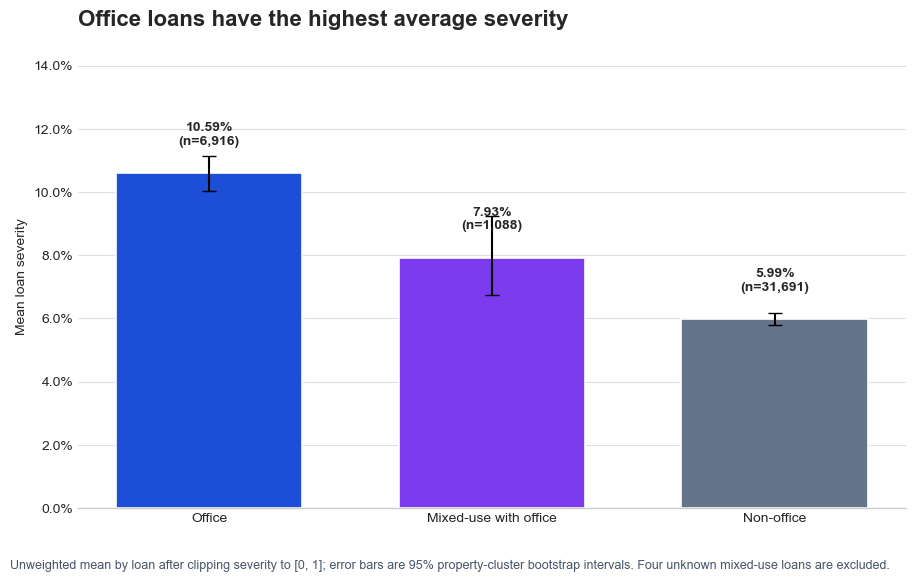

Saved figure to: outputs/figures/part1_office_severity.png


In [7]:
# Reindex explicitly so visual order matches the business question and remains
# stable even if pandas group ordering changes.
figure_data = summary.loc[GROUP_ORDER]
means = figure_data["mean_severity"].to_numpy()
errors = np.vstack(
    [
        means - figure_data["ci_low"].to_numpy(),
        figure_data["ci_high"].to_numpy() - means,
    ]
)

colors = ["#1D4ED8", "#7C3AED", "#64748B"]
# Plot the requested unweighted means; asymmetric error bars carry the
# property-cluster bootstrap interval calculated above.
fig, ax = plt.subplots(figsize=(9.2, 5.8))
bars = ax.bar(
    GROUP_ORDER,
    means,
    yerr=errors,
    capsize=5,
    color=colors,
    edgecolor="white",
    linewidth=1.2,
    width=0.66,
)

for bar, mean, loan_count in zip(bars, means, figure_data["loan_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + 0.008,
        f"{mean:.2%}\n(n={loan_count:,})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="semibold",
    )

ax.set_title("Office loans have the highest average severity", loc="left", fontsize=16, fontweight="bold", pad=14)
ax.set_ylabel("Mean loan severity")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(figure_data["ci_high"]) + 0.035)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", color="#CBD5E1", alpha=0.7)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=10)
ax.tick_params(axis="y", length=0)
fig.text(
    0.01, 0.01,
    "Unweighted mean by loan after clipping severity to [0, 1]; error bars are 95% property-cluster bootstrap intervals. "
    "Four unknown mixed-use loans are excluded.",
    fontsize=9, color="#475569",
)
fig.tight_layout(rect=[0, 0.06, 1, 1])

# Persist a high-resolution copy while retaining the inline notebook display.
figure_path = FIGURE_DIR / "part1_office_severity.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure to: {figure_path.relative_to(ROOT)}")

## 4. Interpretation

On the unweighted loan basis requested, office properties look more distressed. Office loans have the highest average severity, followed by mixed-use properties with offices and then non-office properties. Most of the difference comes from office loans having positive severity more often. Among loans with positive severity, the average loss is much closer across the three groups.

Weaker office occupancy and rent could explain the result, but this comparison does not isolate the effect of remote work. The groups may also differ in leverage, delinquency, location, vintage, property quality, and loan size. For a trading decision, the loan-balance-weighted results are also important because they give more weight to larger exposures.

In [8]:
office = summary.loc["Office"]
mixed = summary.loc["Mixed-use with office"]
non_office = summary.loc["Non-office"]

print(
    "Primary means: "
    f"office={office['mean_severity']:.2%}, "
    f"mixed-use with office={mixed['mean_severity']:.2%}, "
    f"non-office={non_office['mean_severity']:.2%}."
)
print(
    "Positive-loss shares: "
    f"office={office['loss_frequency']:.2%}, "
    f"mixed-use with office={mixed['loss_frequency']:.2%}, "
    f"non-office={non_office['loss_frequency']:.2%}."
)
print(
    "Balance-weighted means: "
    f"office={office['loan_balance_weighted_mean']:.2%}, "
    f"mixed-use with office={mixed['loan_balance_weighted_mean']:.2%}, "
    f"non-office={non_office['loan_balance_weighted_mean']:.2%}."
)

Primary means: office=10.59%, mixed-use with office=7.93%, non-office=5.99%.
Positive-loss shares: office=23.71%, mixed-use with office=18.47%, non-office=14.32%.
Balance-weighted means: office=7.88%, mixed-use with office=5.74%, non-office=7.00%.
